In [266]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [267]:
df = pd.read_csv(r"D:\GitHubRepos\is6400-business-data-analytics\data\further_cleaned_dataset.csv")
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Age,Miles_per_year,Brand_Model
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,1,Hybrid,3.5,186005,6,Automatic,4x4,4,Left wheel,Silver,12,15,12400.333333,LEXUS_RX 450
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,0,Petrol,3.0,192000,6,Tiptronic,4x4,4,Left wheel,Black,8,14,13714.285714,CHEVROLET_Equinox
2,8467,NaN,HONDA,FIT,2006,Hatchback,0,Petrol,1.3,200000,4,Variator,Front,4,Right-hand drive,Black,2,19,10526.315789,HONDA_FIT
3,3607,862.0,FORD,Escape,2011,Jeep,1,Hybrid,2.5,168966,4,Automatic,4x4,4,Left wheel,White,0,14,12069.000000,FORD_Escape
4,11726,446.0,HONDA,FIT,2014,Hatchback,1,Petrol,1.3,91901,4,Automatic,Front,4,Left wheel,Silver,4,11,8354.636364,HONDA_FIT


In [268]:
# 基础缺失值处理（无数据泄露风险）
df['Levy'] = df['Levy'].fillna(df['Levy'].median())
df['Levy'] = df['Levy'].fillna(df['Levy'].median())

In [269]:
# 先划分数据（关键修改点1）
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [270]:
# 定义分类特征（根据数据描述）
cat_features = [
    'Manufacturer', 'Model', 'Category', 'Leather interior',
    'Fuel type', 'Gear box type', 'Drive wheels', 'Doors',
    'Wheel', 'Color', 'Brand_Model'
]

In [271]:
# === 训练集特征工程 ===
# 异常值过滤（仅训练集）
Q1 = train_df['Price'].quantile(0.25)
Q3 = train_df['Price'].quantile(0.75)
IQR = Q3 - Q1
train_df = train_df[~((train_df['Price'] < (Q1 - 1.5 * IQR)) | (train_df['Price'] > (Q3 + 1.5 * IQR)))]

# 合理性过滤（仅训练集）
# train_df = train_df[
#     (train_df['Mileage'] <= 400000) & 
#     (train_df['Engine volume'] <= 6.0) & 
#     (train_df['Prod. year'] >= 1990)
# ]

# 品牌溢价特征（关键修改点2）
brand_avg = train_df.groupby('Manufacturer')['Price'].median().to_dict()
train_df['Brand_price_ratio'] = train_df['Manufacturer'].map(brand_avg)
test_df['Brand_price_ratio'] = test_df['Manufacturer'].map(brand_avg)  # 使用训练集参数

# 组合特征
train_df['Mileage_per_year'] = train_df['Mileage'] / (train_df['Age'] + 1)
train_df['Engine_power'] = train_df['Engine volume'] * train_df['Cylinders']

# 时间特征
# train_df['Is_modern'] = (train_df['Prod. year'] >= 2015).astype(int)

# 对数转换
train_df['Log_mileage'] = np.log1p(train_df['Mileage'])

In [272]:
# === 测试集特征工程 ===
# 应用相同转换（使用训练集生成的参数）
test_df['Mileage_per_year'] = test_df['Mileage'] / (test_df['Age'] + 1)
test_df['Engine_power'] = test_df['Engine volume'] * test_df['Cylinders']
# test_df['Is_modern'] = (test_df['Prod. year'] >= 2015).astype(int)
test_df['Log_mileage'] = np.log1p(test_df['Mileage'])

In [273]:
# === 公共处理 ===
# 删除冗余特征
for df in [train_df, test_df]:
    df.drop(columns=['Age'], inplace=True)

In [274]:
from sklearn.base import BaseEstimator, TransformerMixin

class SafeLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.encoder = LabelEncoder()
        self.unknown_code = -1  # 为未知类别分配特殊编码
    
    def fit(self, X):
        self.encoder.fit(X)
        return self
    
    def transform(self, X):
        encoded = np.full_like(X, self.unknown_code, dtype=int)
        for i, val in enumerate(X):
            if val in self.encoder.classes_:
                encoded[i] = self.encoder.transform([val])[0]
        return encoded



In [275]:
# 修改编码部分
encoders = {}
for col in cat_features:
    encoder = SafeLabelEncoder()
    train_df[col] = encoder.fit_transform(train_df[col].astype(str))
    test_df[col] = encoder.transform(test_df[col].astype(str))
    encoders[col] = encoder
    
# 验证未知类别处理
print("测试集中未知车型数量:", (test_df['Model'] == -1).sum())

测试集中未知车型数量: 114


In [276]:
# 设置分类列类型
train_df[cat_features] = train_df[cat_features].astype('category')
test_df[cat_features] = test_df[cat_features].astype('category')

In [277]:
train_df.describe()

,Price,Levy,Prod. year,Engine volume,Mileage,Cylinders,Airbags,Miles_per_year,Brand_price_ratio,Mileage_per_year,Engine_power,Log_mileage
count,11146.000000,11146.000000,11146.000000,11146.000000,1.114600e+04,11146.000000,11146.000000,1.114600e+04,11146.000000,1.114600e+04,11146.000000,11146.000000
mean,14776.298224,867.888121,2011.337072,2.331105,1.041037e+06,4.606047,6.835008,4.946918e+04,12567.430917,4.692185e+04,11.574529,11.289599
std,12107.419857,404.848755,4.806480,0.894317,3.940914e+07,1.198592,4.358061,1.655298e+06,3667.269078,1.581102e+06,8.113037,2.311178
min,1.000000,87.000000,1985.000000,0.000000,0.000000e+00,1.000000,0.000000,0.000000e+00,3293.000000,0.000000e+00,0.000000,0.000000
25%,4704.000000,690.000000,2010.000000,1.800000,7.840600e+04,4.000000,4.000000,6.546198e+03,9722.000000,6.000000e+03,7.200000,11.269668
50%,13172.000000,781.000000,2012.000000,2.000000,1.326300e+05,4.000000,6.000000,1.000000e+04,12231.000000,9.273292e+03,8.000000,11.795326
75%,21012.000000,919.000000,2014.000000,2.500000,1.966820e+05,5.000000,12.000000,1.385131e+04,17562.000000,1.285714e+04,12.000000,12.189349
max,50196.000000,11714.000000,2020.000000,20.000000,2.147484e+09,16.000000,16.000000,9.761289e+07,17562.000000,9.336885e+07,87.600000,21.487563


In [278]:
# 准备数据
X_train = train_df.drop(columns=['Price'])
y_train = np.log1p(train_df['Price'])  # 对数转换

X_test = test_df.drop(columns=['Price'])
y_test = np.log1p(test_df['Price'])

In [280]:
import optuna

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2),
        'depth': trial.suggest_int('depth', 12, 15),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 5, 10),
        'random_strength': trial.suggest_int('random_strength', 5, 20),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'grow_policy': trial.suggest_categorical('grow_policy', ['Depthwise', 'Lossguide']),
        'cat_features': cat_features  # 关键修复点
    }
    
    model = CatBoostRegressor(
        task_type='GPU',  # 启用GPU加速
        devices='0:1',    # 使用第0号GPU的1号计算核心
        iterations=1000,
        eval_metric='RMSE',
        early_stopping_rounds=50,
        **params
    )
    
    # 添加分类特征验证
    try:
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            verbose=0,
            use_best_model=True
        )
    except Exception as e:
        print(f"参数 {params} 导致错误: {str(e)}")
        return float('inf')  # 返回极大值表示失败
    
    return model.get_best_score()['validation']['RMSE']

# 执行优化
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, timeout=3600)  # 设置1小时超时

# 输出最佳参数
print("最佳参数:", study.best_params)

[I 2025-03-30 04:10:28,264] A new study created in memory with name: no-name-2afec5fb-4e41-4c83-b53f-5202dc8fee8d
[I 2025-03-30 04:10:41,962] Trial 0 finished with value: 0.9910614285987593 and parameters: {'learning_rate': 0.12501373777739822, 'depth': 15, 'l2_leaf_reg': 9.372673644973652, 'random_strength': 13, 'bagging_temperature': 0.3927497043062351, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.9910614285987593.
[I 2025-03-30 04:10:48,944] Trial 1 finished with value: 1.007950966556978 and parameters: {'learning_rate': 0.15315494274398378, 'depth': 15, 'l2_leaf_reg': 5.764344397128099, 'random_strength': 13, 'bagging_temperature': 0.6807099574932745, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.9910614285987593.
[I 2025-03-30 04:11:04,940] Trial 2 finished with value: 0.989429711836381 and parameters: {'learning_rate': 0.0818987543980074, 'depth': 14, 'l2_leaf_reg': 8.88699691397389, 'random_strength': 19, 'bagging_temperature': 0.25445434311237647, 'gr

最佳参数: {'learning_rate': 0.12880079432902872, 'depth': 14, 'l2_leaf_reg': 9.896733326103902, 'random_strength': 11, 'bagging_temperature': 0.5809956844831486, 'grow_policy': 'Depthwise'}


In [281]:
# === 最终模型 ===
best_model = CatBoostRegressor(
    **study.best_params,
    cat_features=cat_features,
    iterations=2000,
    eval_metric='RMSE',
    early_stopping_rounds=100
)

In [282]:
# 训练模型
best_model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=100)

0:	learn: 1.5653951	test: 1.5553380	best: 1.5553380 (0)	total: 108ms	remaining: 3m 34s
100:	learn: 0.8904230	test: 1.0834465	best: 1.0834465 (100)	total: 9.93s	remaining: 3m 6s
200:	learn: 0.6321880	test: 1.0241270	best: 1.0240746 (199)	total: 27.2s	remaining: 4m 3s
300:	learn: 0.4385305	test: 1.0116130	best: 1.0116130 (300)	total: 48s	remaining: 4m 31s
400:	learn: 0.3548988	test: 1.0107774	best: 1.0103617 (369)	total: 1m 2s	remaining: 4m 7s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 1.010361687
bestIteration = 369

Shrink model to first 370 iterations.


In [284]:
# === 评估 ===
y_pred = np.expm1(best_model.predict(X_test))
y_true = np.expm1(y_test)

print(f'''
评估结果:
RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.2f}
MAE: {mean_absolute_error(y_true, y_pred):.2f}
R² Score: {r2_score(y_true, y_pred):.4f}
''')


评估结果:
RMSE: 14139.69
MAE: 6729.09
R² Score: 0.3655



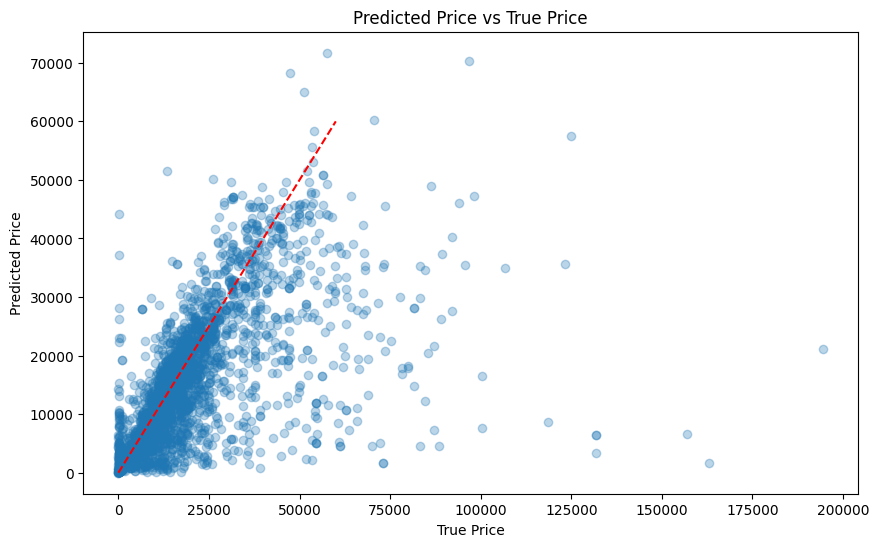

In [285]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_true, y_pred, alpha=0.3)
plt.plot([0, 60000], [0, 60000], 'r--')
plt.xlabel("True Price")
plt.ylabel("Predicted Price")
plt.title("Predicted Price vs True Price")
plt.show()